In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime as dt
import plotly.express as px
from numpy import median

In [2]:
fb_ads = pd.read_csv(r'C:\Users\Acer\Downloads\facebook_ads_data (2.0).csv')

1.1 Зроби групування даних по днях та для згрупованих даних побудуй графік з щоденною сумою витрат на рекламу у 2021 році

In [3]:
fb_ads['ad_date'] = pd.to_datetime(fb_ads['ad_date'])
fb_ads_pd_tot_spd = fb_ads.groupby('ad_date', as_index=False)['total_spend'].sum()
fb_ads_pd_tot_spd_2021 = fb_ads_pd_tot_spd[(fb_ads_pd_tot_spd['ad_date'] <= '31-12-2021') 
                                           & (fb_ads_pd_tot_spd['ad_date'] >= '01-01-2021')].reset_index()

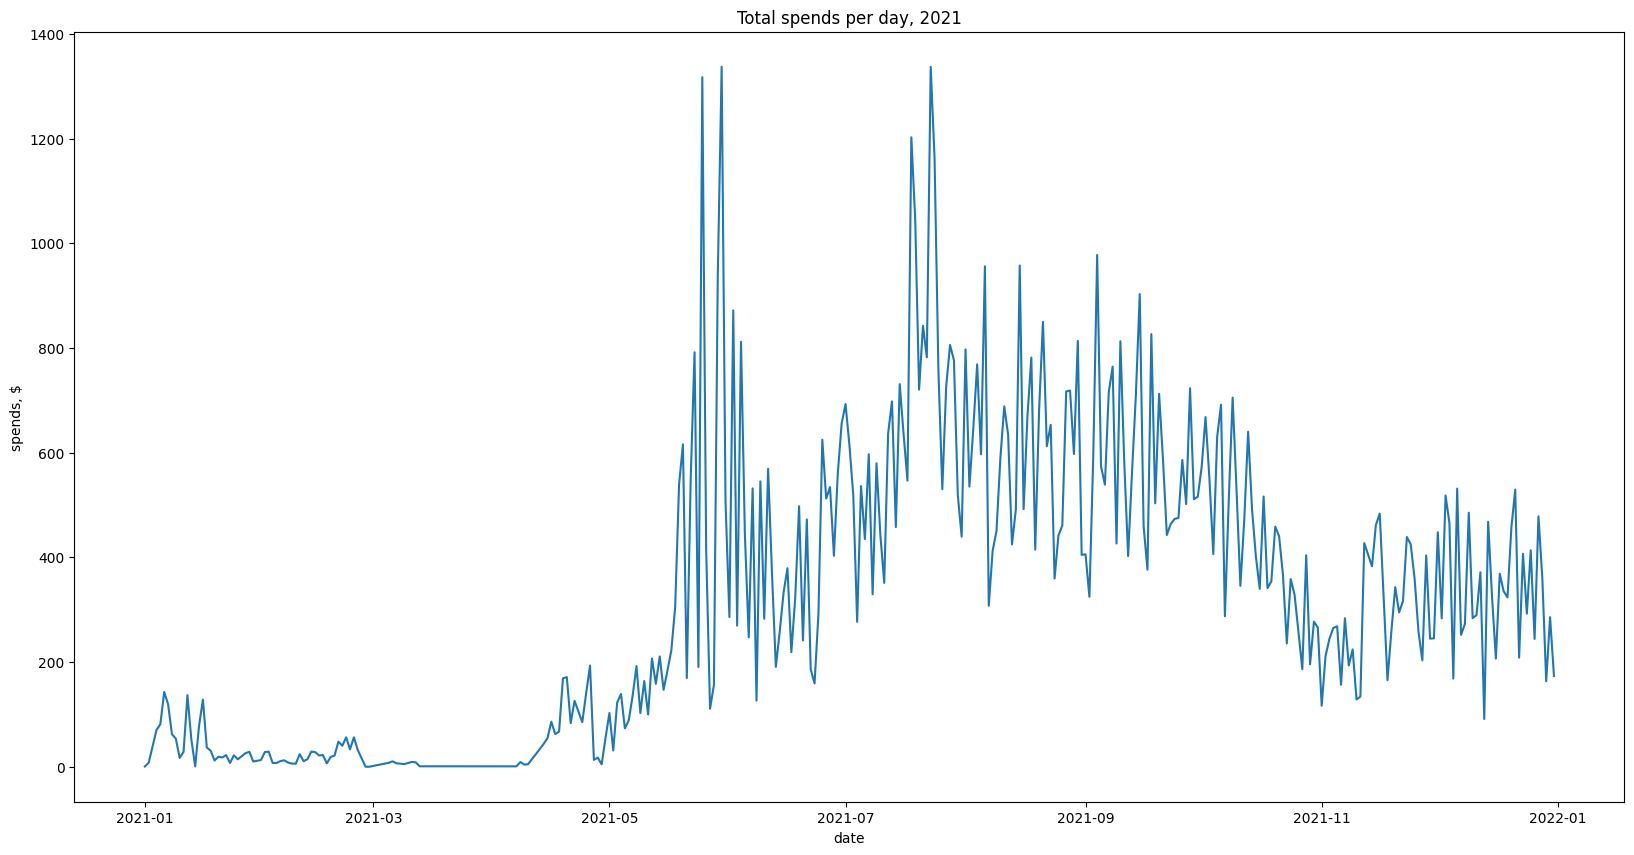

In [4]:
plt.figure(figsize=(20, 10))
plt.plot('ad_date', 'total_spend', data=fb_ads_pd_tot_spd_2021)
plt.title('Total spends per day, 2021')
plt.xlabel('date')
plt.ylabel('spends, $')
plt.show()


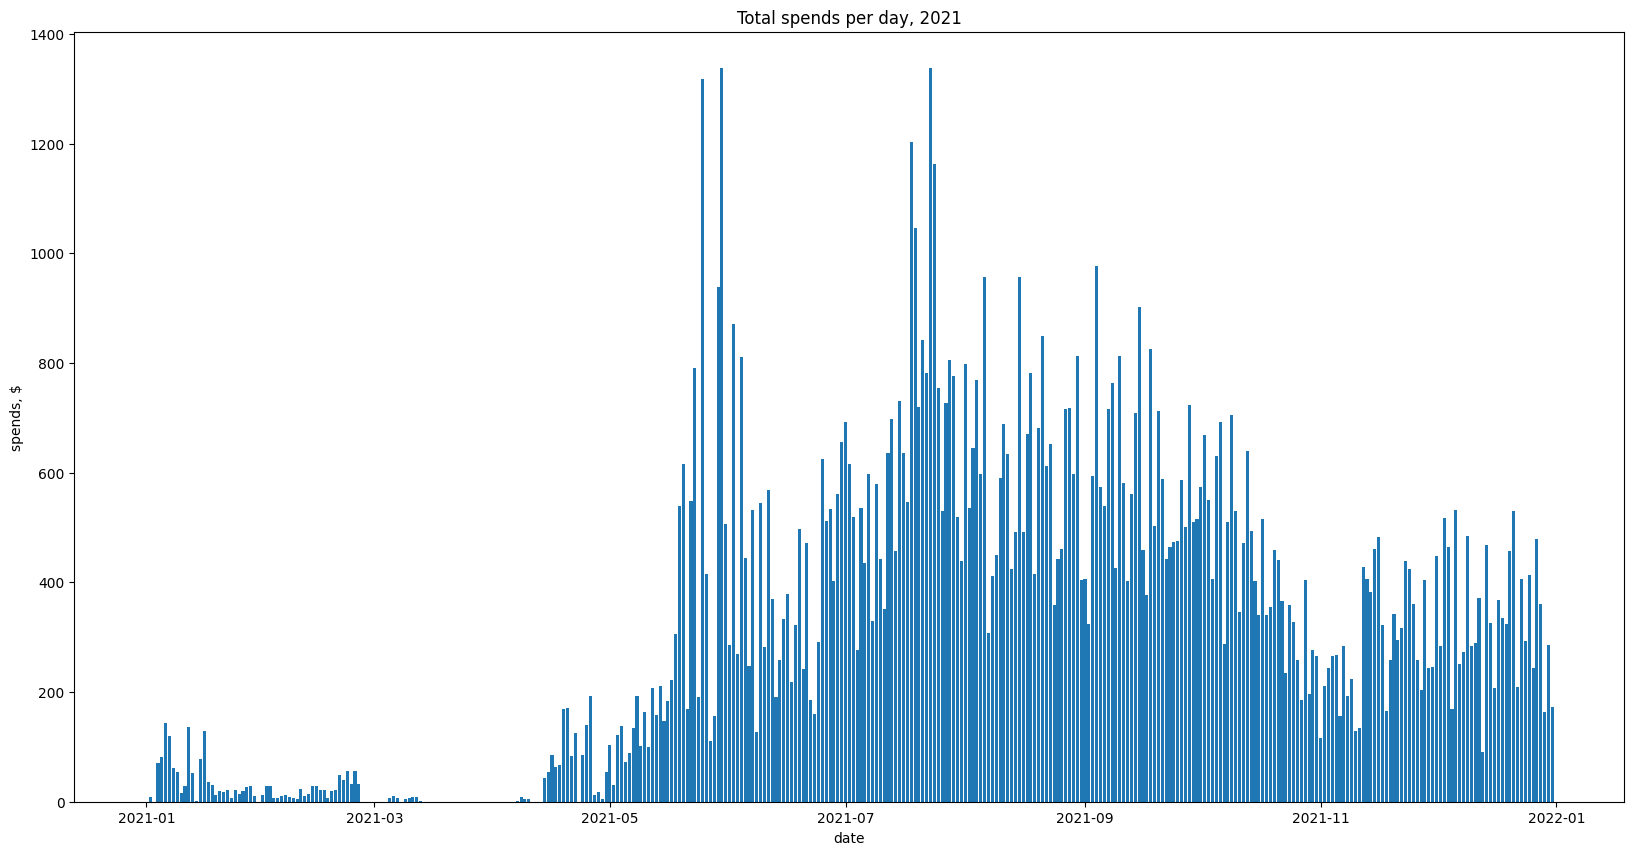

In [5]:
plt.figure(figsize=(20, 10))
plt.bar('ad_date', 'total_spend', data=fb_ads_pd_tot_spd_2021)
plt.title('Total spends per day, 2021')
plt.xlabel('date')
plt.ylabel('spends, $')
plt.show()

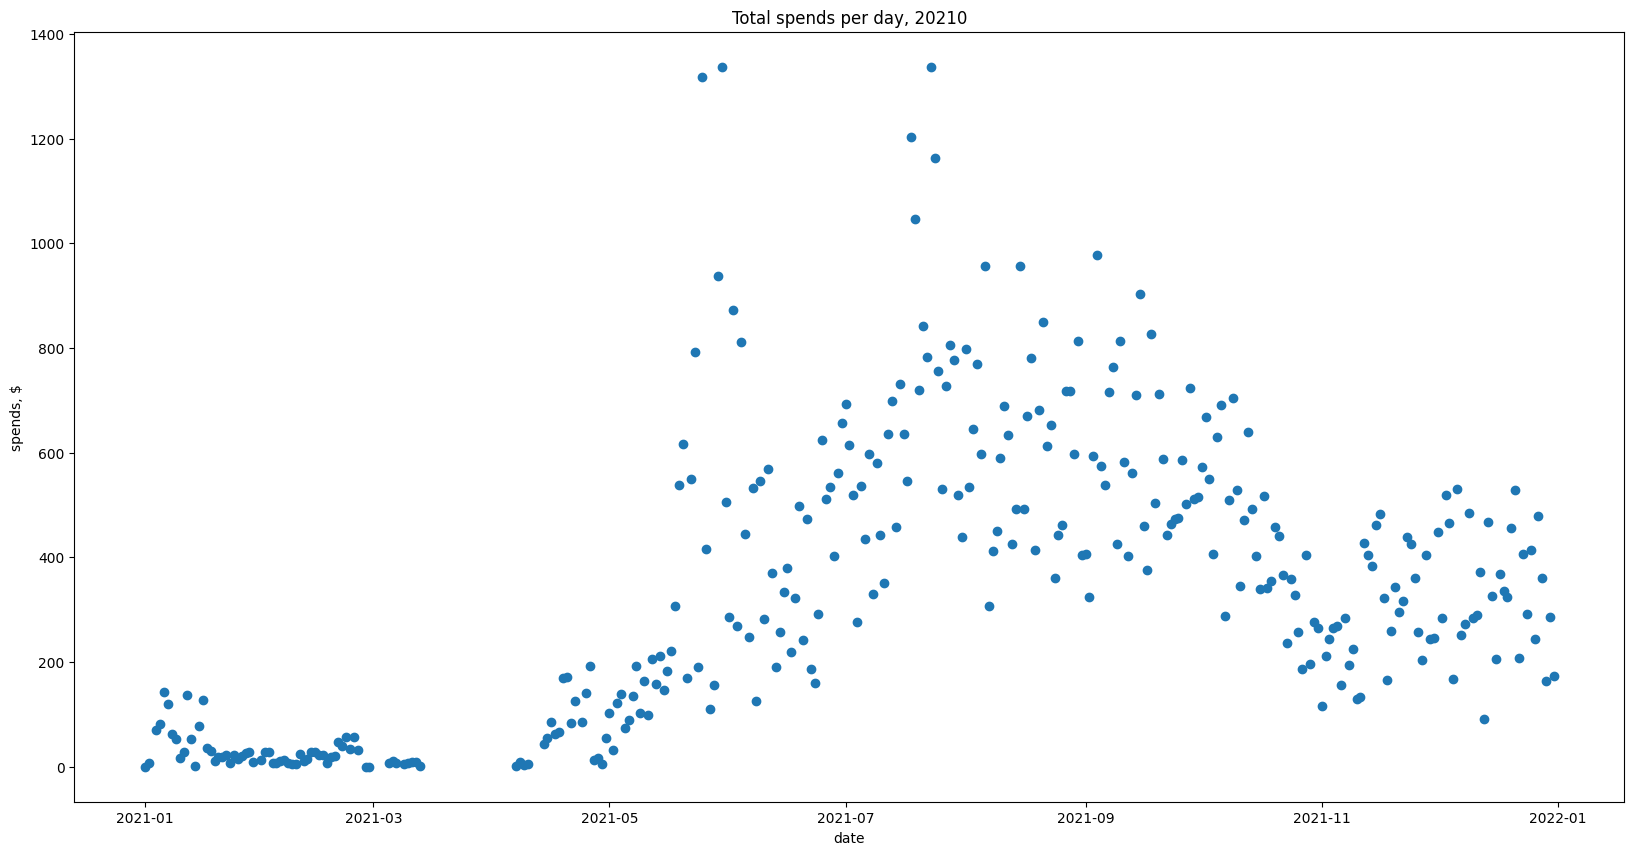

In [6]:
plt.figure(figsize=(20, 10))
plt.scatter(x='ad_date', y='total_spend', data=fb_ads_pd_tot_spd_2021, marker='o')
plt.title('Total spends per day, 20210')
plt.xlabel('date')
plt.ylabel('spends, $')
plt.show()

1.2 Зроби групування даних по днях та для згрупованих даних побудуй графік з щоденним ROMI у 2021 році.

In [7]:
fb_ads_pd_romi = fb_ads.groupby('ad_date', as_index=False)['romi'].mean()
fb_ads_pd_romi_2021 = fb_ads_pd_romi[(fb_ads_pd_romi['ad_date'] <= '31-12-2021') 
                                     & (fb_ads_pd_romi['ad_date'] >= '01-01-2021')].reset_index()

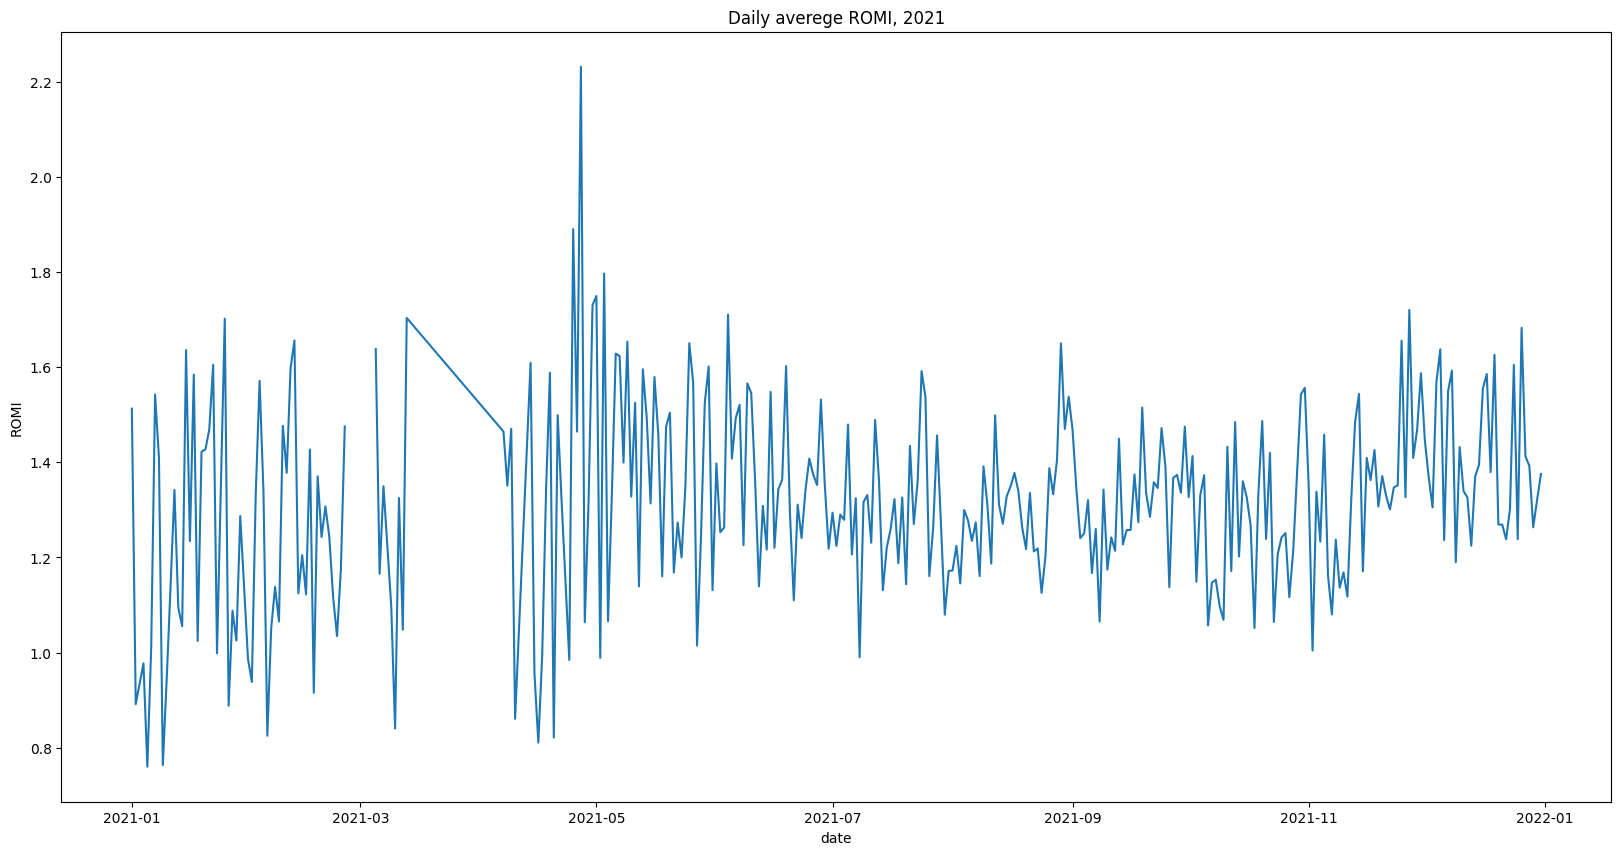

In [8]:
plt.figure(figsize=(20, 10))
plt.plot('ad_date', 'romi', data=fb_ads_pd_romi_2021)
plt.title('Daily averege ROMI, 2021')
plt.xlabel('date')
plt.ylabel('ROMI')
plt.show()


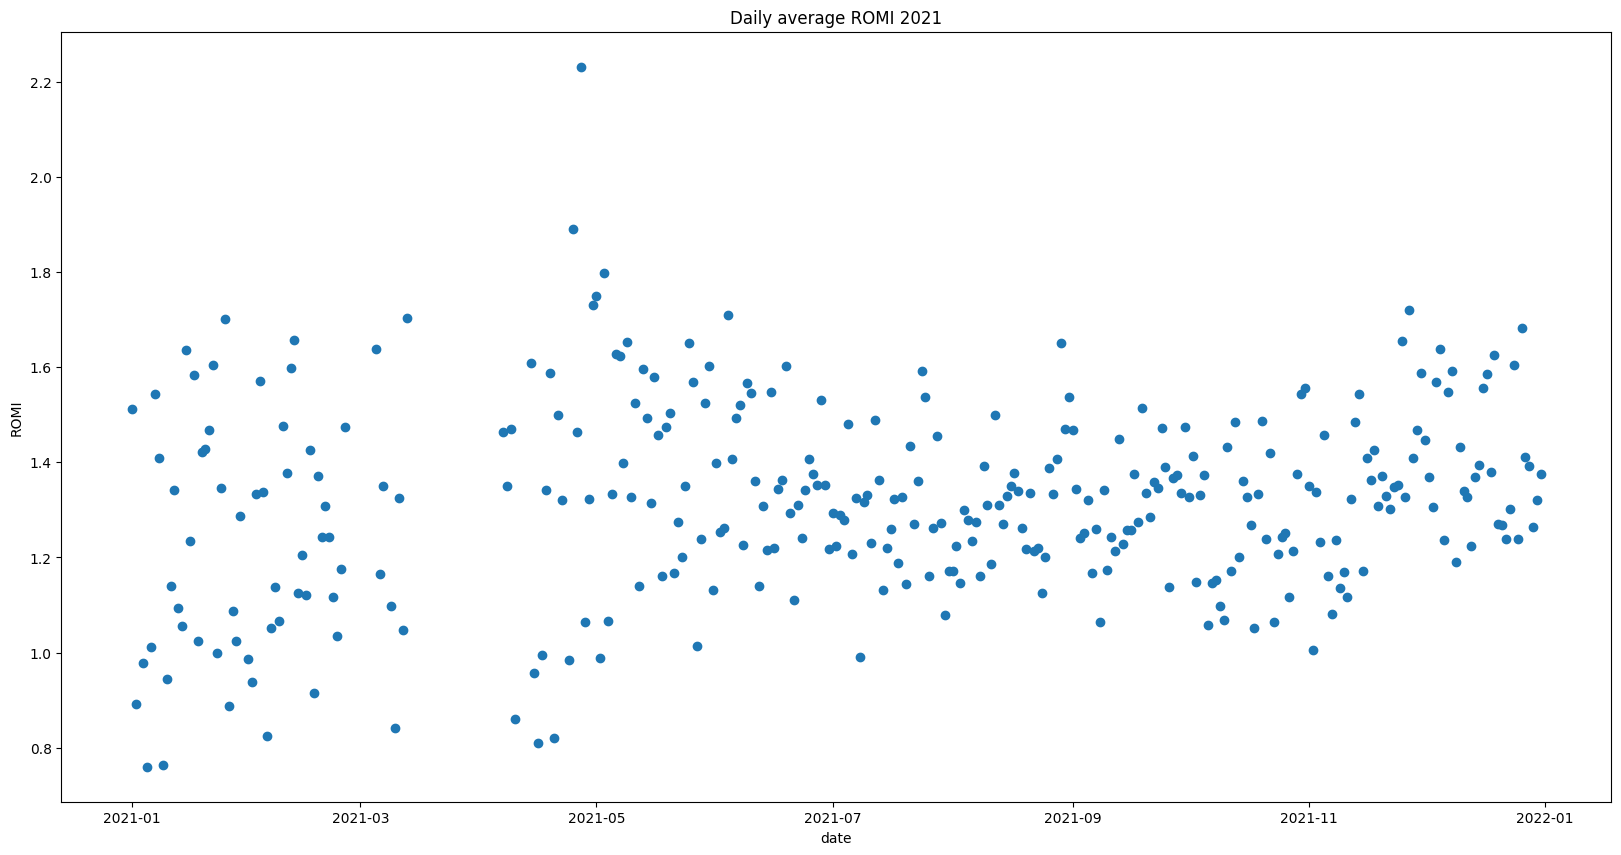

In [9]:
plt.figure(figsize=(20, 10))
plt.scatter(x='ad_date', y='romi', data=fb_ads_pd_romi_2021)
plt.title('Daily average ROMI 2021')
plt.xlabel('date')
plt.ylabel('ROMI')
plt.show()

Бонусне мінізавдання: Застосуй метод rolling() щоб відобразити рухоме середніх витрат та ROMI

Text(0, 0.5, 'ROMI')

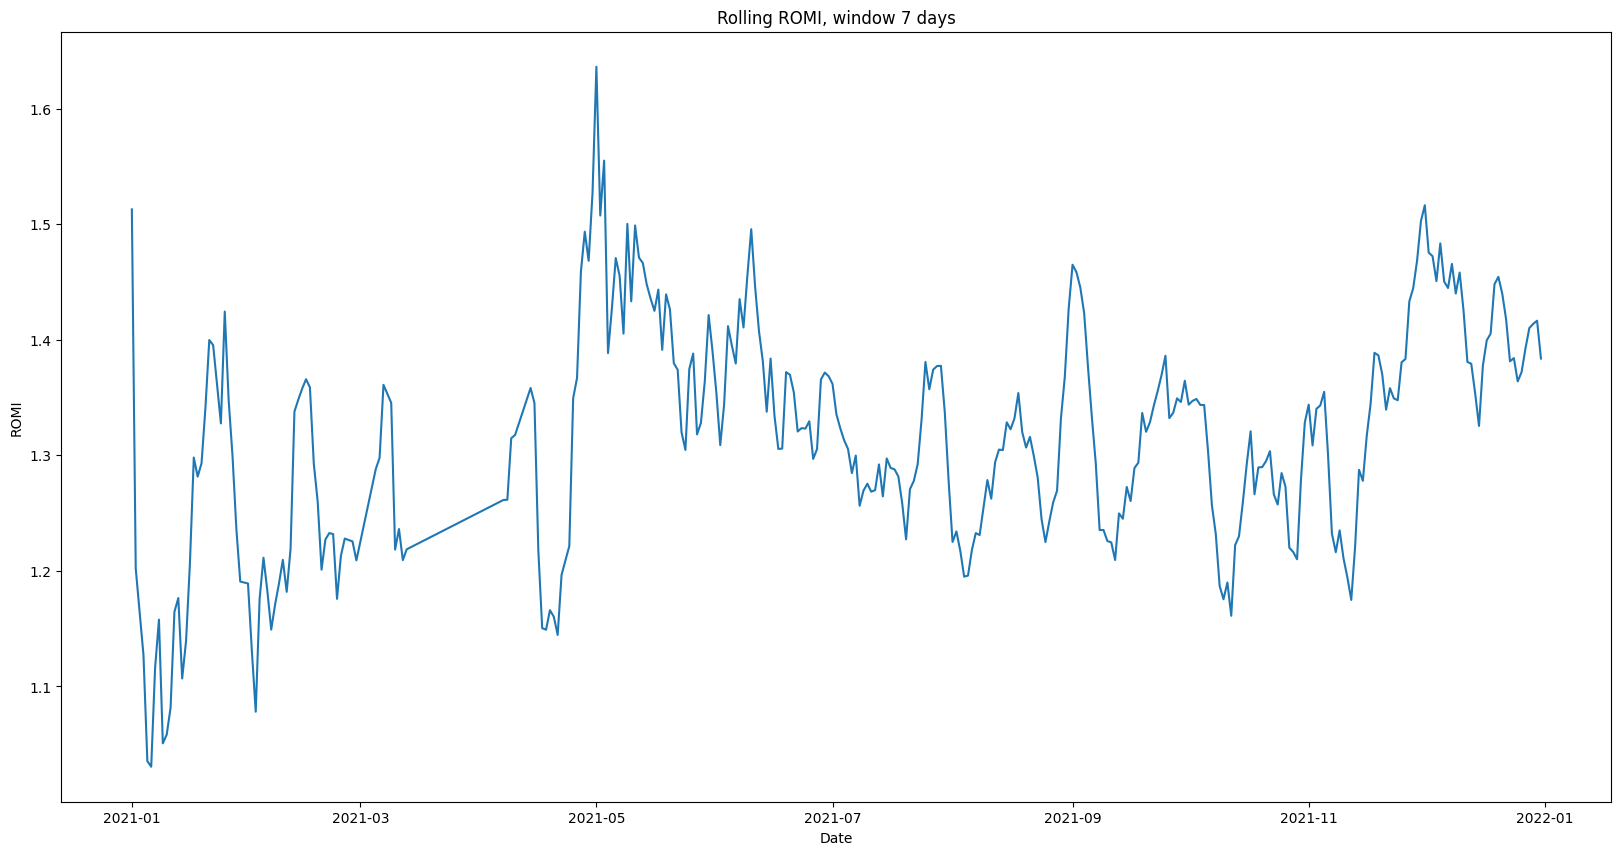

In [10]:
fb_ads_pd_romi_2021['cumulative'] = fb_ads_pd_romi_2021['romi'].rolling(window=7, min_periods=1).mean()
plt.figure(figsize=(20, 10))
sns.lineplot(fb_ads_pd_romi_2021, x='ad_date', y='cumulative')

plt.title('Rolling ROMI, window 7 days')
plt.xlabel('Date')
plt.ylabel('ROMI')


2.1 Зроби групування даних за назвою кампанії і побудуй графік загальної суми витрат на рекламу в кожній з кампаній

In [11]:
fb_ads_campanies = fb_ads.groupby('campaign_name').agg({
    'total_spend': 'sum',
    'romi': 'mean'
}).reset_index()

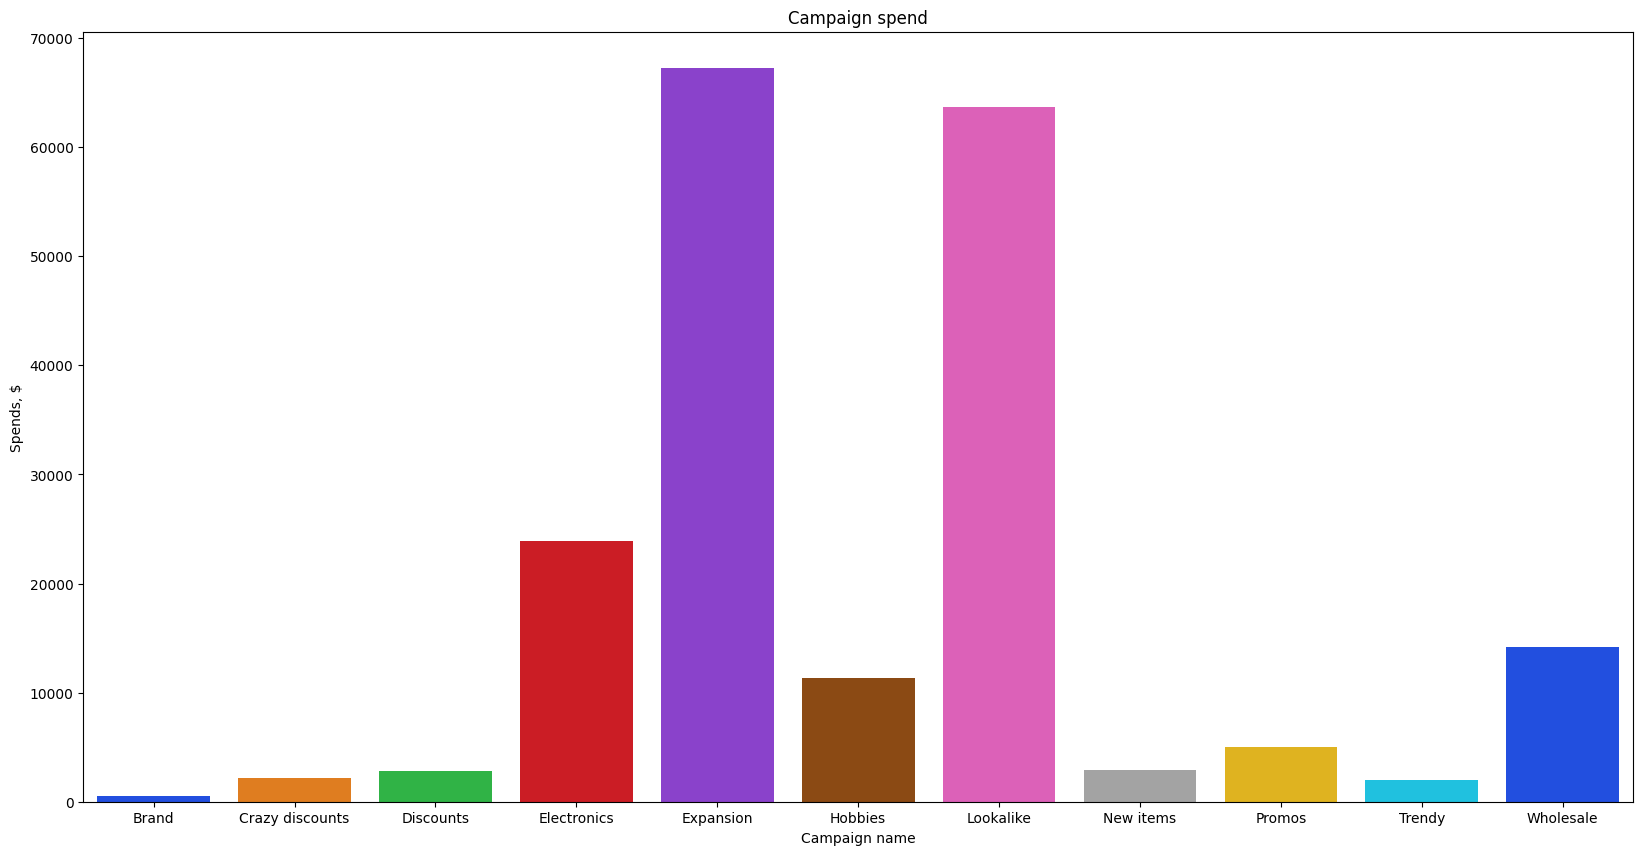

In [12]:
plt.figure(figsize=(20, 10))
sns.barplot(data = fb_ads_campanies, x='campaign_name', y='total_spend', palette= 'bright', hue='campaign_name', legend= False, width=0.8)
plt.title('Campaign spend')
plt.xlabel('Campaign name')
plt.ylabel('Spends, $')
plt.show()

2.2 Зроби групування даних за назвою кампанії і побудуй загальний ROMI в кожній з кампаній

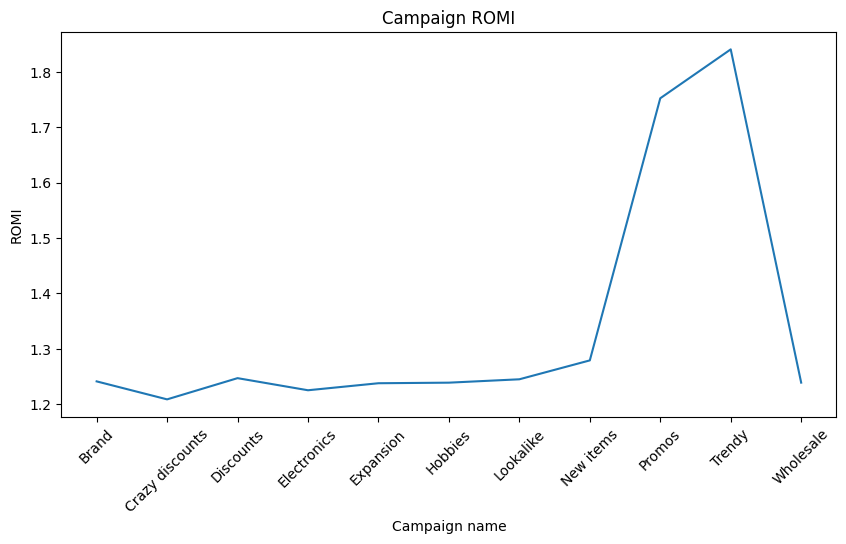

In [13]:
plt.figure(figsize = (10, 5))
plt.plot('campaign_name', 'romi', data = fb_ads_campanies)
plt.title('Campaign ROMI')
plt.xlabel('Campaign name')
plt.xticks(rotation = 45)
plt.ylabel('ROMI')
plt.show()

3. За допомогою box plot визнач, яким був розкид щоденного ROMI в кожній кампанії (за назвою кампанії.)

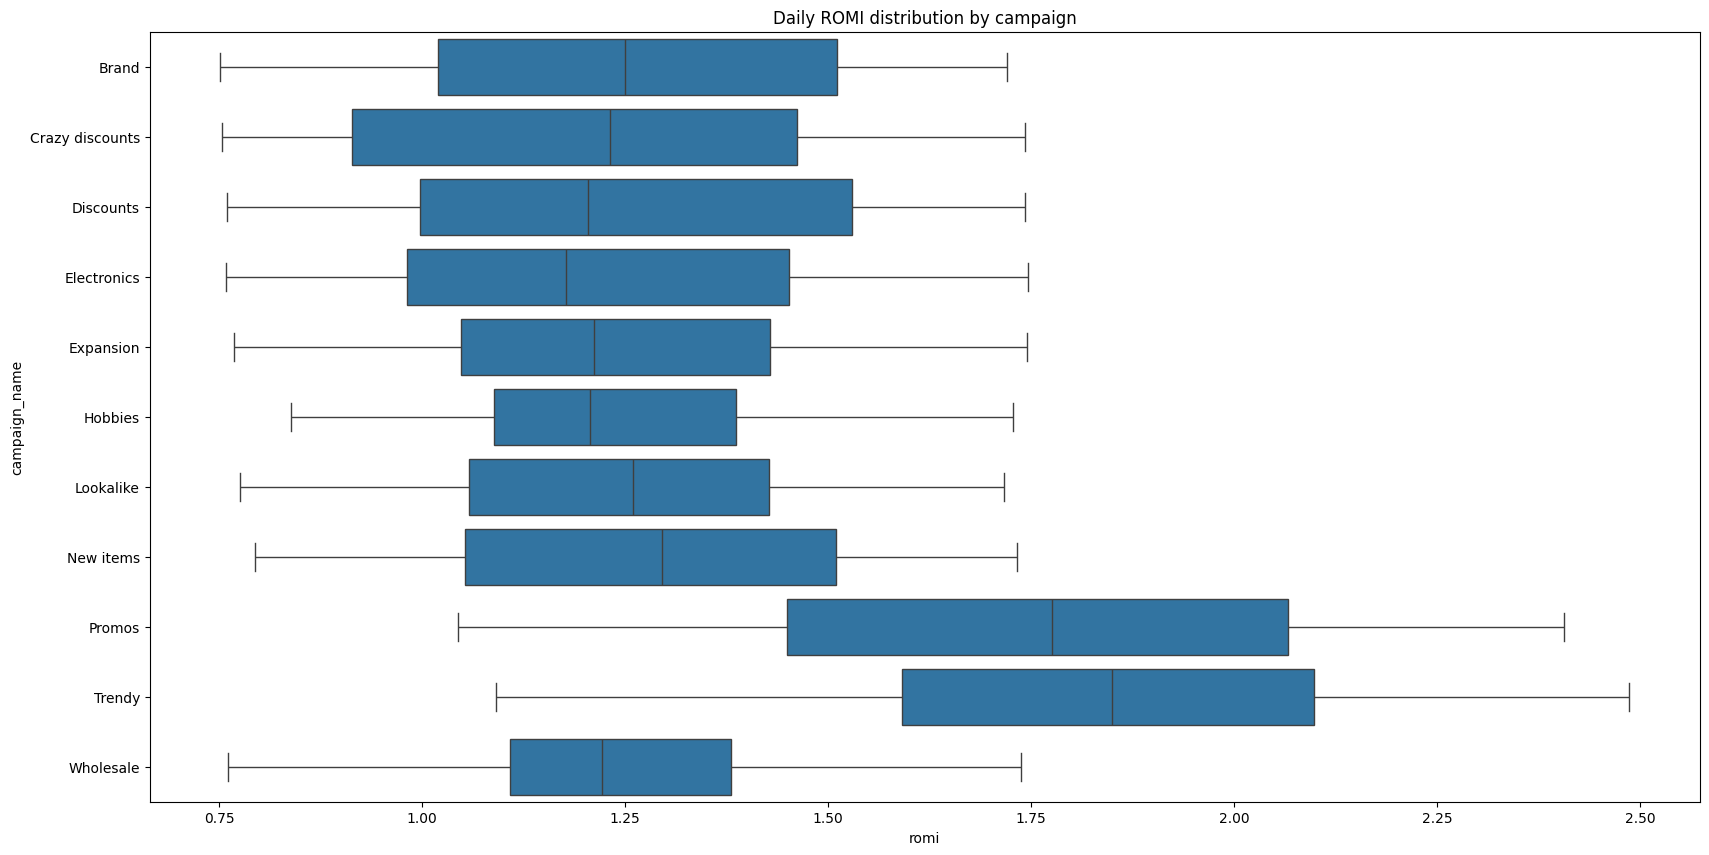

In [14]:
fb_ads_campanies_dail_romi = fb_ads.groupby(['campaign_name', 'ad_date'])['romi'].mean().reset_index()
#fb_ads_companies_dail_romi

plt.figure(figsize= (20, 10))
sns.boxplot(fb_ads_campanies_dail_romi, x='romi', y='campaign_name')
plt.title('Daily ROMI distribution by campaign')
plt.show()

4. Побудуй гістограму з розподілом значень ROMI в таблиці facebook_ads_data.csv

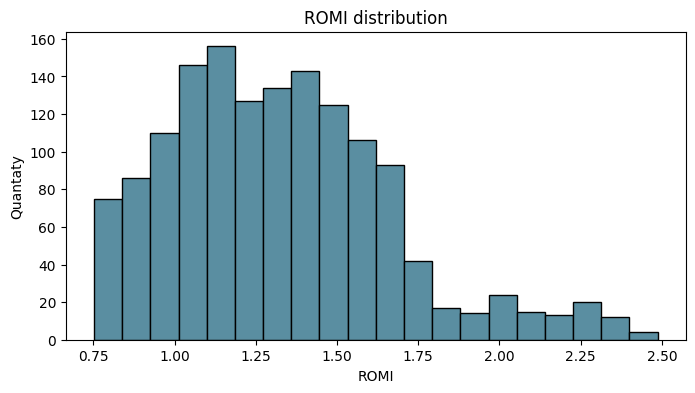

In [15]:
plt.figure(figsize = (8, 4))
plt.hist(fb_ads['romi'].dropna(), bins=20, color = '#5a8ea1', edgecolor = 'black')
plt.title('ROMI distribution')
plt.xlabel('ROMI')
plt.ylabel('Quantaty')
plt.show()

5. Побудуй теплову карту кореляції між усіма числовими показниками в таблиці facebook_ads_data.csv. Які показники мають найвищу та найнижчу кореляцію? З чим корелює "total_value"?

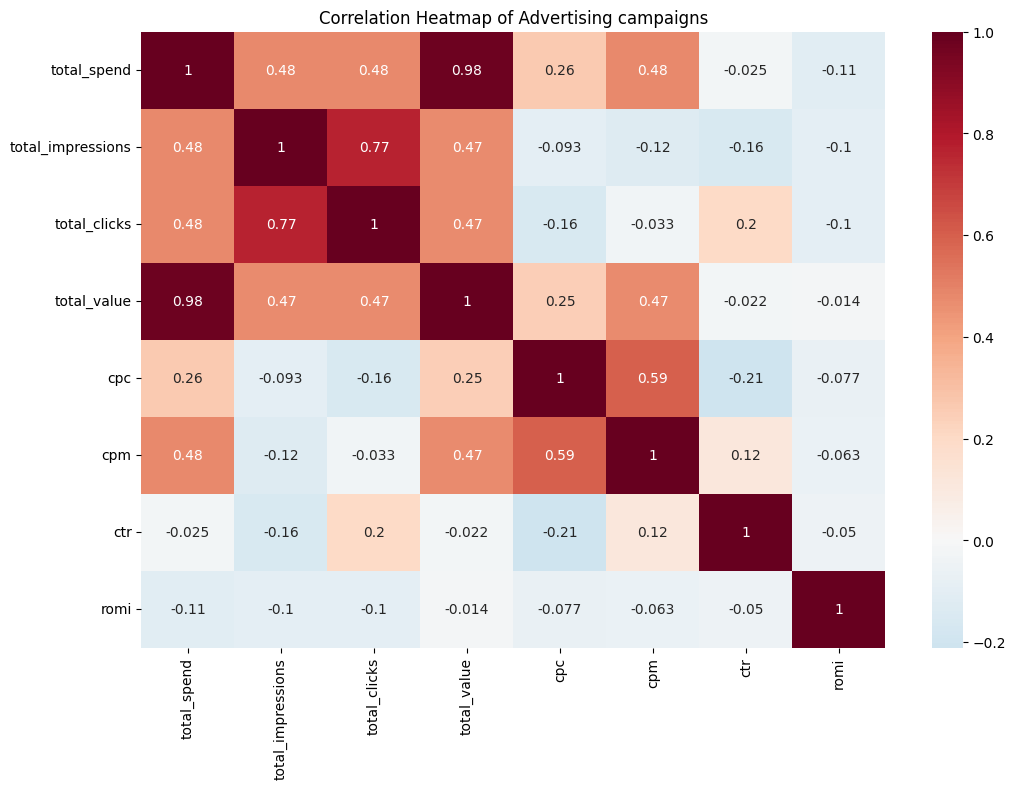

In [16]:
numeric_cols = ['total_spend', 'total_impressions', 'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi']
cor_matrix = fb_ads[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(cor_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Advertising campaigns')
plt.show()


З heatmap видно, що: найвищу кореляцію мають 'total_spend'/'total_value', а також 'total_impressions'/'total_clicks'. Найнижчу: 'total_value'/'romi', а також 'total_spend'/'ctr'. Показник 'total_value' корелює найбільше з 'total_spend', як було зазаначено вище, але кореляція із 'total_impressions', 'total_clicks', 'ctr' є суттєвою в однаковій мірі.

6. Побудуй точкову діаграму з лінійною регресією (для цього ти можеш використати функцію lmplot()), що побудована на даних з "total_spend" та "total_value" щоб візуалізувати звʼязок між цими величинами.

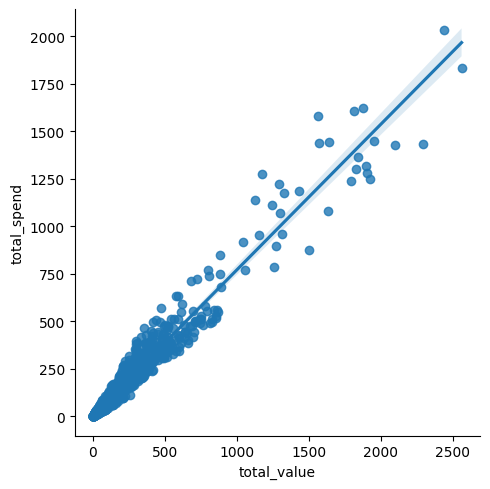

In [17]:
sns.lmplot(fb_ads, x='total_value', y='total_spend')
plt.show()